<a href="https://colab.research.google.com/github/RyantRamadhan/ImamAryantaRamadhan_2411532001_ML2526/blob/main/Praktikum4/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


In [8]:
dataset_url = 'https://raw.githubusercontent.com/RyantRamadhan/ImamAryantaRamadhan_2411532001_ML2526/refs/heads/main/Praktikum4/advertising.csv'
df = pd.read_csv(dataset_url)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

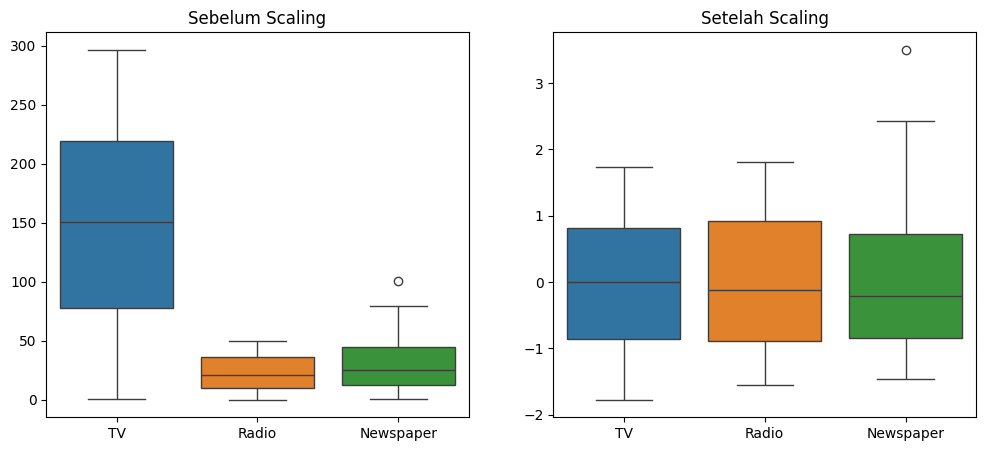

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)


Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)



Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [13]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)



Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


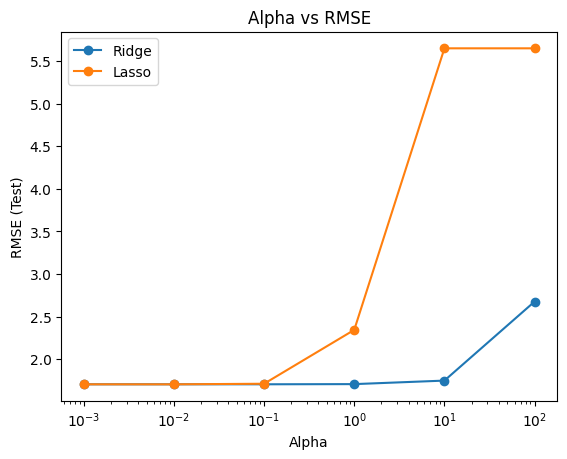

In [14]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

In [15]:
alphas_baru = [0.005, 0.05, 0.5, 5, 50]

ridge_rmse_baru = []
lasso_rmse_baru = []

for a in alphas_baru:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_rmse_baru.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))

    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    lasso_rmse_baru.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

print("RMSE Ridge baru:", ridge_rmse_baru)
print("RMSE Lasso baru:", lasso_rmse_baru)

RMSE Ridge baru: [np.float64(1.7052243393359807), np.float64(1.70531241085699), np.float64(1.7062544713703818), np.float64(1.7213971097834393), np.float64(2.149022156976447)]
RMSE Lasso baru: [np.float64(1.7050968174353074), np.float64(1.7061554767985292), np.float64(1.9086891689830876), np.float64(5.648216567255986), np.float64(5.648216567255986)]


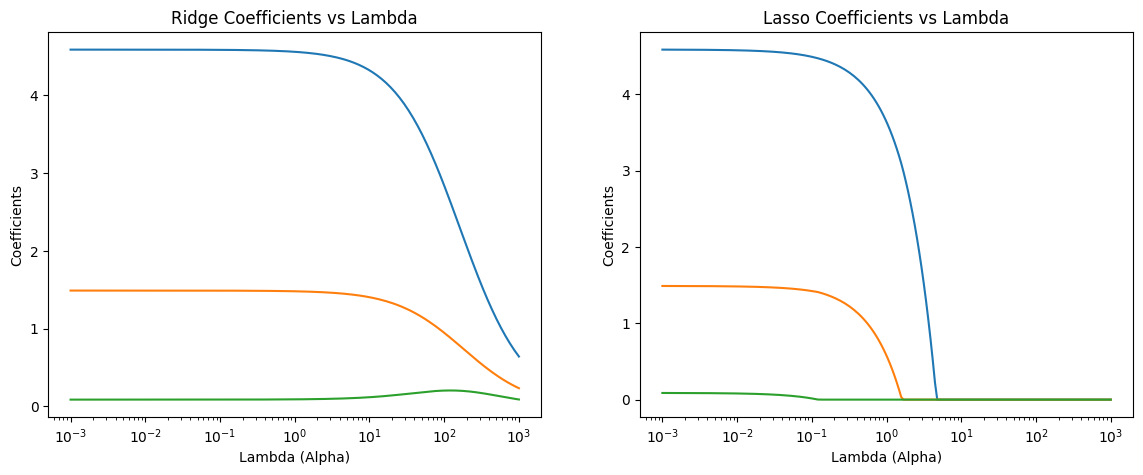

In [16]:
alphas_plot = np.logspace(-3, 3, 200)
ridge_coefs = []
lasso_coefs = []

for a in alphas_plot:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)

    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    lasso_coefs.append(l.coef_)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(alphas_plot, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_xlabel('Lambda (Alpha)')
ax[0].set_ylabel('Coefficients')
ax[0].set_title('Ridge Coefficients vs Lambda')

ax[1].plot(alphas_plot, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_xlabel('Lambda (Alpha)')
ax[1].set_ylabel('Coefficients')
ax[1].set_title('Lasso Coefficients vs Lambda')

plt.show()